In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [137]:
df = pd.read_csv("../data/OTT.csv")
df.head()

,구분별(1),구분별(2),2025,2025.1,2025.2,2025.3,2025.4,2025.5,2025.6,2025.7,...,2020.2,2020.3,2020.4,2020.5,2020.6,2020.7,2020.8,2020.9,2020.10,2020.11
0,구분별(1),구분별(2),웨이브(Wavve) (%),티빙(Tving) (%),U+모바일 TV (%),네이버 TV(구 네이버NOW) (%),위버스 (%),SOOP(구 아프리카TV) (%),왓챠 (%),카카오 TV (%),...,U+모바일 TV (%),곰TV (%),위버스 (%),SOOP(구 아프리카TV) (%),왓챠 (%),넷플릭스 (%),유튜브(유튜브 프리미엄 구독) (%),시즌 (%),기타 (%),이중에 이용한적 없음 (%)
1,전체,소계,4.1,13.0,0.9,0.1,0.2,0.1,1.5,0.3,...,1.1,0.0,0.1,0.3,0.3,11.6,8.2,0.5,0.0,78.3
2,성별,남자,3.9,12.0,0.8,0.1,0.2,0.0,1.7,0.0,...,1.3,0.0,0.0,0.4,0.2,10.8,9.1,0.4,0.0,77.3
3,성별,여자,4.2,14.1,1.0,0.1,0.2,0.1,1.3,0.5,...,0.8,0.1,0.3,0.1,0.5,12.4,7.2,0.6,0.1,79.3
4,연령,10대,2.3,24.7,1.5,0.0,1.3,0.0,1.4,2.1,...,3.1,0.0,0.0,0.5,0.1,11.4,6.1,2.1,0.0,79.6


In [138]:
df.iloc[0].unique()

<StringArray>
[                   '구분별(1)',                    '구분별(2)',
            '웨이브(Wavve) (%)',             '티빙(Tving) (%)',
              'U+모바일 TV (%)',      '네이버 TV(구 네이버NOW) (%)',
                   '위버스 (%)',        'SOOP(구 아프리카TV) (%)',
                    '왓챠 (%)',                '카카오 TV (%)',
     '쿠팡플레이 (쿠팡와우 이용자만) (%)',                   '라프텔 (%)',
               '스포티비 나우 (%)',               '네이버 치지직 (%)',
                  '넷플릭스 (%)',                '디즈니플러스 (%)',
                '아마존프라임 (%)',                 '애플TV+ (%)',
      '유튜브(유튜브 프리미엄 구독) (%)',         '틱톡(틱톡 라이브 구독) (%)',
                   '펄스픽 (%)',                 '드라마박스 (%)',
           '이중에 이용한적 없음 (%)',                   '곰TV (%)',
 '네이버 시리즈온 (동영상 시청에 한함) (%)',   '카카오페이지 (동영상 시청에 한함) (%)',
                   '트위치 (%)',                    '시즌 (%)',
                    '기타 (%)']
Length: 29, dtype: str

In [139]:
mask_list1 = ['지역', '직업', '학력', '주거형태', '방송이용 유형', '지역유형']
mask_list2 = ['구분별(1)', '구분별(2)', '웨이브(Wavve) (%)', '티빙(Tving) (%)', '왓챠 (%)', '쿠팡플레이 (쿠팡와우 이용자만) (%)', 
              '넷플릭스 (%)','디즈니플러스 (%)', '아마존프라임 (%)', '애플TV+ (%)',
              '유튜브(유튜브 프리미엄 구독) (%)', '이중에 이용한적 없음 (%)']

df = df[~df['구분별(1)'].isin(mask_list1)]
df = df.loc[:, df.iloc[0].isin(mask_list2)]
df['구분별(1)'].unique()
df.iloc[0].unique()

<StringArray>
[               '구분별(1)',                '구분별(2)',        '웨이브(Wavve) (%)',
         '티빙(Tving) (%)',                '왓챠 (%)', '쿠팡플레이 (쿠팡와우 이용자만) (%)',
              '넷플릭스 (%)',            '디즈니플러스 (%)',            '아마존프라임 (%)',
             '애플TV+ (%)',  '유튜브(유튜브 프리미엄 구독) (%)',       '이중에 이용한적 없음 (%)']
Length: 12, dtype: str

In [140]:
# 연도별 열을 하나의 분석용 DataFrame으로 변환
def make_long_df(df):
    common_cols = df.columns[:2].tolist()
    service_row = df.iloc[0]
    data_rows = df.iloc[1:]
    long_parts = []

    for col in df.columns[2:]:
        part = data_rows[common_cols].copy()
        part["연도"] = str(col)[:4]
        part["서비스"] = service_row[col]
        part["이용률"] = pd.to_numeric(data_rows[col], errors="coerce")
        long_parts.append(part)

    return pd.concat(long_parts, ignore_index=True)



df_long = make_long_df(df)
df_long

,구분별(1),구분별(2),연도,서비스,이용률
0,전체,소계,2025,웨이브(Wavve) (%),4.1
1,성별,남자,2025,웨이브(Wavve) (%),3.9
2,성별,여자,2025,웨이브(Wavve) (%),4.2
3,연령,10대,2025,웨이브(Wavve) (%),2.3
4,연령,20대,2025,웨이브(Wavve) (%),8.5
...,...,...,...,...,...
1453,가족구성,1인가구,2020,이중에 이용한적 없음 (%),72.5
1454,가족구성,1세대가구,2020,이중에 이용한적 없음 (%),82.2
1455,가족구성,2세대가구,2020,이중에 이용한적 없음 (%),78.8
1456,가족구성,3세대가구,2020,이중에 이용한적 없음 (%),83.6


#### 국내/외 OTT 서비스 연도별 변화

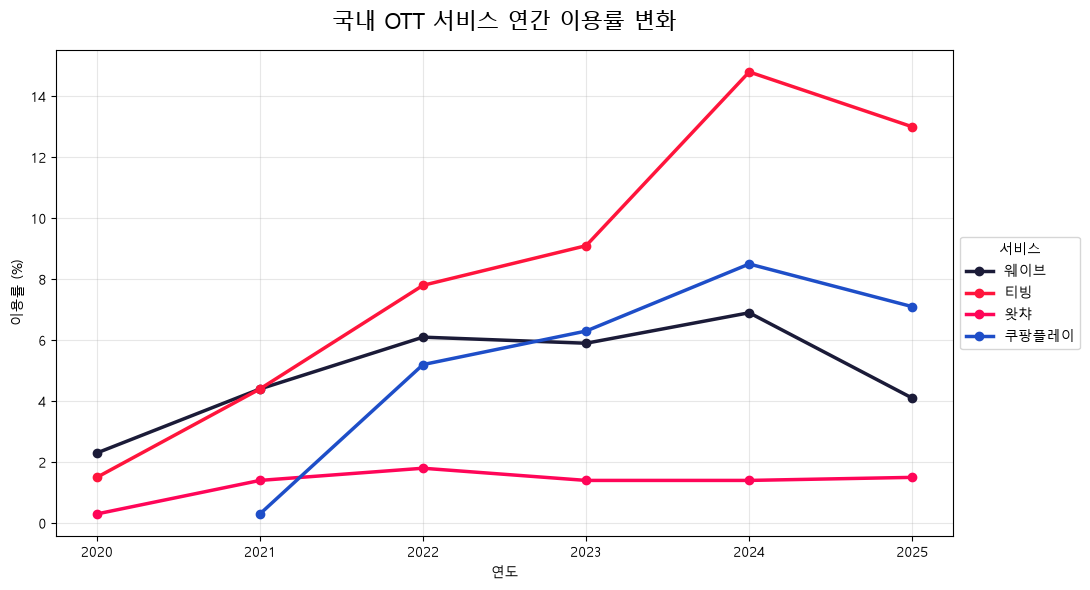

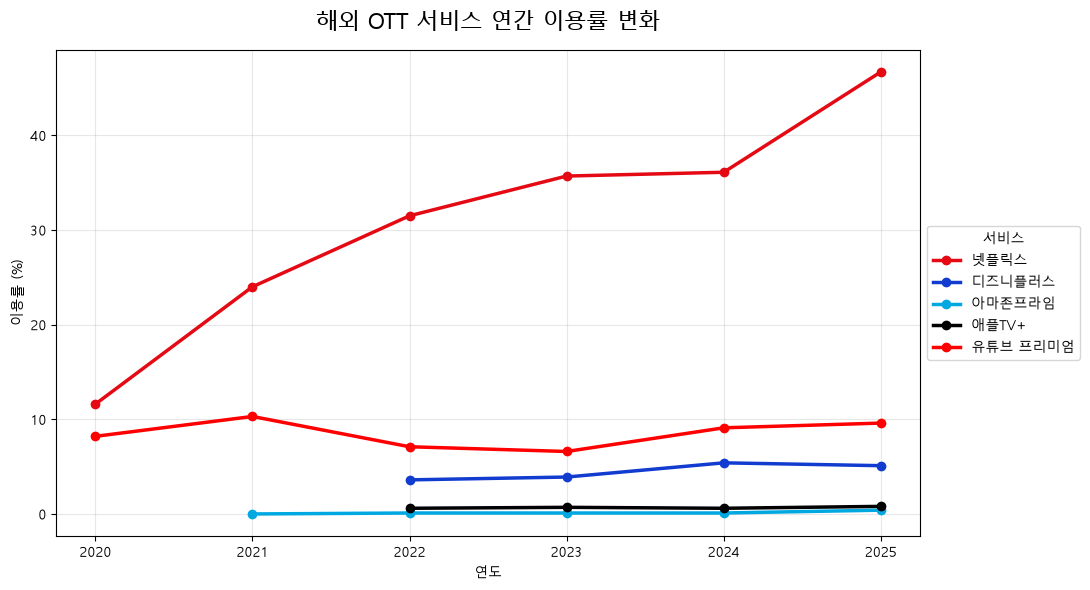

In [141]:
# 전체 응답자(전체·소계)의 서비스 이용률만 추출
overall_usage = df_long[
    (df_long["구분별(1)"] == "전체")
    & (df_long["구분별(2)"] == "소계")
].copy()

# '이용경험 없음'을 제외한 9개 서비스의 연도별 이용률
# 서비스명 일부로 선택해 연도마다 부연 문구가 달라도 같은 서비스를 모을 수 있게 함
def plot_yearly_services(service_info, title):
    fig, ax = plt.subplots(figsize=(11, 6))

    for label, keyword, color in service_info:
        yearly_usage = overall_usage[
            overall_usage["서비스"].str.contains(keyword, regex=False, na=False)
        ].sort_values("연도")
        ax.plot(
            yearly_usage["연도"], yearly_usage["이용률"],
            marker="o", linewidth=2.5, color=color, label=label
        )

    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlabel("연도")
    ax.set_ylabel("이용률 (%)")
    ax.grid(alpha=0.3)
    ax.legend(title="서비스", loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()


# 국내 OTT 대표 브랜드 색상: Wavve 네이비, TVING 레드, WATCHA 핑크, Coupang Play 블루
domestic_services = [
    ("웨이브", "웨이브", "#1B1B38"),
    ("티빙", "티빙", "#FF153C"),
    ("왓챠", "왓챠", "#FF0558"),
    ("쿠팡플레이", "쿠팡플레이", "#1E4EC8"),
]
plot_yearly_services(domestic_services, "국내 OTT 서비스 연간 이용률 변화")

# 해외 OTT 대표 브랜드 색상: Netflix 레드, Disney+ 블루, Prime Video 스카이블루, Apple TV+ 블랙, YouTube Premium 레드
overseas_services = [
    ("넷플릭스", "넷플릭스", "#E50914"),
    ("디즈니플러스", "디즈니플러스", "#113CCF"),
    ("아마존프라임", "아마존프라임", "#00A8E1"),
    ("애플TV+", "애플TV+", "#000000"),
    ("유튜브 프리미엄", "유튜브", "#FF0000"),
]
plot_yearly_services(overseas_services, "해외 OTT 서비스 연간 이용률 변화")

### 분석 방향
1. 넷플릭스는 어떻게 1위면서 더 성장할까?
2. 왓챠의 성장?
3. 쿠팡플레이의 부진?

#### 연도별 순위 및 증감폭 분석

In [142]:
# '이용경험 없음'을 제외하고 서비스별 이용률을 연도별 표로 정리
rank_source = overall_usage[
    ~overall_usage["서비스"].str.contains("이중에 이용한적 없음", na=False)
].copy()

# 이용률 표: 행은 서비스, 열은 연도
years = sorted(rank_source["연도"].unique(), key=int)
usage_by_year = rank_source.pivot_table(
    index="서비스", columns="연도", values="이용률", aggfunc="first"
).reindex(columns=years)

# 같은 연도 안에서 이용률이 높을수록 1위
rank_by_year = usage_by_year.rank(axis=0, ascending=False, method="min").astype("Int64")
first_year, last_year = years[0], years[-1]
rank_change = rank_by_year[last_year] - rank_by_year[first_year]

def describe_rank_change(change):
    if pd.isna(change):
        return "비교 불가"
    if change < 0:
        return f"{-change}위 상승"
    if change > 0:
        return f"{change}위 하락"
    return "변화 없음"

rank_result = rank_by_year.copy()
rank_result["순위 변화"] = rank_change.map(describe_rank_change)
rank_result = rank_result.sort_values(last_year)

print("연도별 이용률 순위 (1위가 가장 높은 이용률)")
display(rank_result)

# 첫 연도와 마지막 연도의 이용률 차이: 양수면 증가, 단위는 %p
change_summary = usage_by_year.copy()
change_summary["증감폭 (%p)"] = change_summary[last_year] - change_summary[first_year]
change_summary = change_summary.sort_values("증감폭 (%p)", ascending=False)

print(f"이용률 증감폭: {first_year}년 → {last_year}년")
display(change_summary.round(1))

연도별 이용률 순위 (1위가 가장 높은 이용률)


연도,2020,2021,2022,2023,2024,2025,순위 변화
서비스,,,,,,,
넷플릭스 (%),1,1,1,1,1,1,변화 없음
티빙(Tving) (%),4,3,2,2,2,2,2.0위 상승
유튜브(유튜브 프리미엄 구독) (%),2,2,3,3,3,3,1.0위 하락
쿠팡플레이 (쿠팡와우 이용자만) (%),<NA>,6,5,4,4,4,비교 불가
디즈니플러스 (%),<NA>,<NA>,6,6,6,5,비교 불가
웨이브(Wavve) (%),3,3,4,5,5,6,3.0위 하락
왓챠 (%),5,5,7,7,7,7,2.0위 하락
애플TV+ (%),<NA>,<NA>,8,8,8,8,비교 불가
아마존프라임 (%),<NA>,7,9,9,9,9,비교 불가


이용률 증감폭: 2020년 → 2025년


연도,2020,2021,2022,2023,2024,2025,증감폭 (%p)
서비스,,,,,,,
넷플릭스 (%),11.6,24.0,31.5,35.7,36.1,46.7,35.1
티빙(Tving) (%),1.5,4.4,7.8,9.1,14.8,13.0,11.5
웨이브(Wavve) (%),2.3,4.4,6.1,5.9,6.9,4.1,1.8
유튜브(유튜브 프리미엄 구독) (%),8.2,10.3,7.1,6.6,9.1,9.6,1.4
왓챠 (%),0.3,1.4,1.8,1.4,1.4,1.5,1.2
디즈니플러스 (%),NaN,NaN,3.6,3.9,5.4,5.1,NaN
아마존프라임 (%),NaN,0.0,0.1,0.1,0.1,0.4,NaN
애플TV+ (%),NaN,NaN,0.6,0.7,0.6,0.8,NaN
쿠팡플레이 (쿠팡와우 이용자만) (%),NaN,0.3,5.2,6.3,8.5,7.1,NaN


#### 연도별 이용률 증감 Heatmap (안써도 될듯)

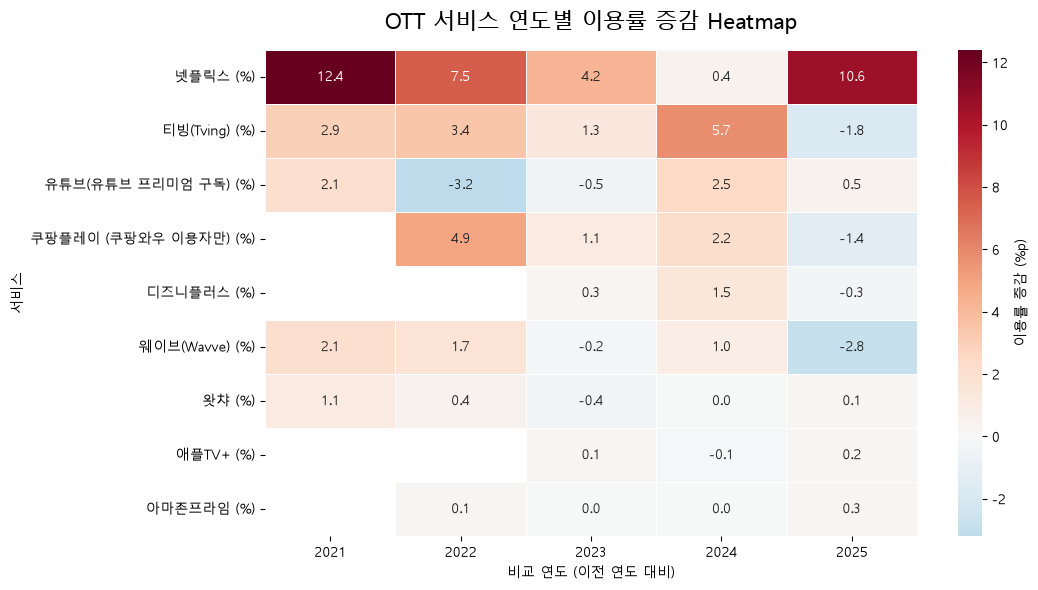

In [143]:
# 바로 이전 연도와 비교한 이용률 증감(%p)을 색으로 표시
yearly_change = usage_by_year.diff(axis=1).iloc[:, 1:]
yearly_change = yearly_change.loc[usage_by_year[last_year].sort_values(ascending=False).index]

plt.figure(figsize=(11, max(6, len(yearly_change) * 0.45)))
sns.heatmap(
    yearly_change, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
    linewidths=0.5, cbar_kws={"label": "이용률 증감 (%p)"}
)
plt.title("OTT 서비스 연도별 이용률 증감 Heatmap", fontsize=16, pad=15)
plt.xlabel("비교 연도 (이전 연도 대비)")
plt.ylabel("서비스")
plt.tight_layout()
plt.show()

## 인구통계별 OTT 이용률 분석

분석 기간은 2020~2025년입니다. 성별과 연령은 동일한 항목을 유지하므로 전체 기간을 비교하고, 소득은 공통 구간과 고소득 구간을 분리해 해석합니다.

#### OTT별 핵심 고객 분석
- 연령별, 성별, 소득수준 분석!

In [159]:
# 분석에 사용할 주요 OTT와 연도 순서
analysis_services = {
    "넷플릭스": "넷플릭스",
    "티빙": "티빙",
    # "웨이브": "웨이브",
    "쿠팡플레이": "쿠팡플레이",
    "유튜브 프리미엄": "유튜브",
    # "디즈니플러스": "디즈니플러스",
}
analysis_years = sorted(df_long["연도"].unique(), key=int)

def demographic_service_data(group, categories, keyword):
    """한 인구통계 집단의 특정 서비스 이용률을 뽑아 표 형태로 반환한다."""
    data = df_long[
        (df_long["구분별(1)"] == group)
        & (df_long["구분별(2)"].isin(categories))
        & (df_long["서비스"].str.contains(keyword, regex=False, na=False))
    ].copy()
    return data.pivot_table(
        index="구분별(2)", columns="연도", values="이용률", aggfunc="first"
    ).reindex(index=categories, columns=analysis_years)

def first_last_change(table):
    """첫 연도와 마지막 연도가 모두 있을 때만 증감폭(%p)을 계산한다."""
    return table[analysis_years[-1]] - table[analysis_years[0]]

## 1. 성별: 전체 장기추이와 성별 격차

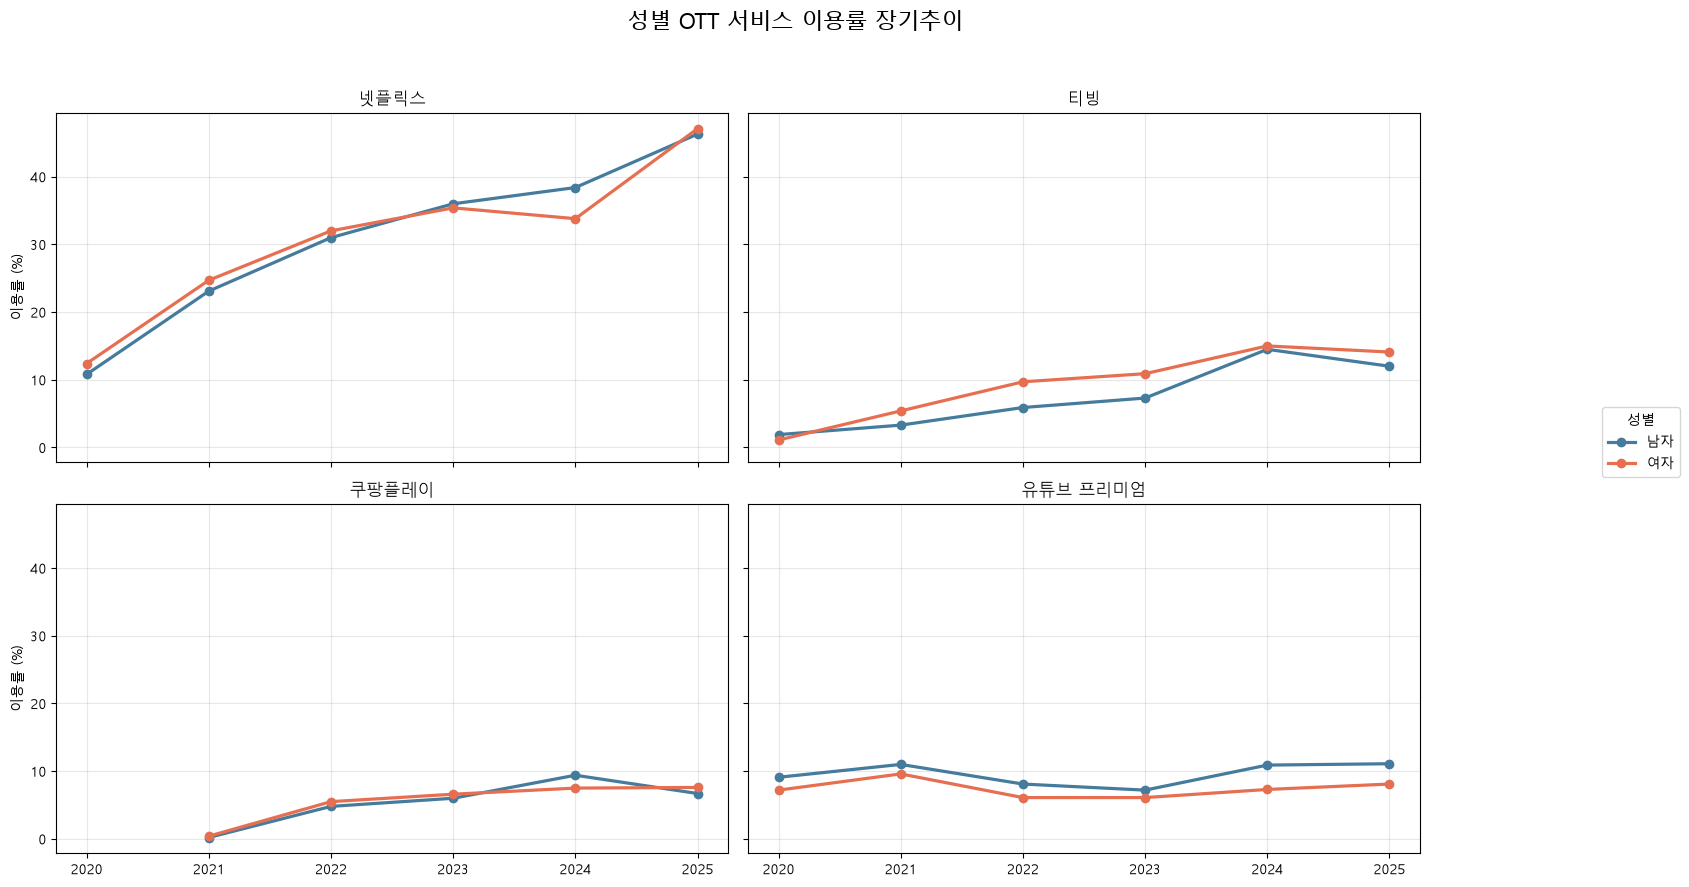

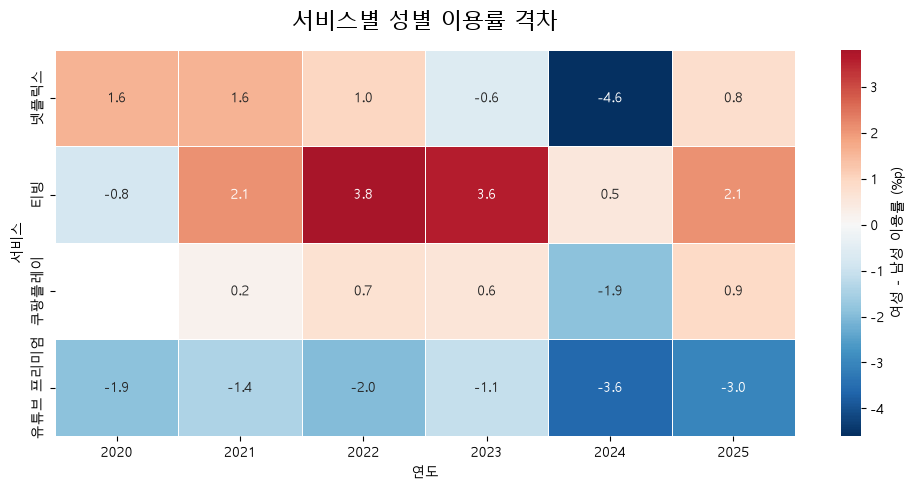

In [160]:
gender_categories = ["남자", "여자"]
gender_colors = {"남자": "#457B9D", "여자": "#E76F51"}

# fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)

for ax, (service_name, keyword) in zip(axes.flat, analysis_services.items()):
    table = demographic_service_data("성별", gender_categories, keyword)
    for gender in gender_categories:
        ax.plot(table.columns, table.loc[gender], marker="o", linewidth=2.3,
                color=gender_colors[gender], label=gender)
    ax.set_title(service_name)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("이용률 (%)")
axes[1, 0].set_ylabel("이용률 (%)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="성별", loc="center left", bbox_to_anchor=(1, 0.5))
fig.suptitle("성별 OTT 서비스 이용률 장기추이", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

# 여성 이용률 - 남성 이용률. 양수는 여성 이용률이 더 높다는 뜻
gender_gap = pd.DataFrame({
    service_name: (
        demographic_service_data("성별", gender_categories, keyword).loc["여자"]
        - demographic_service_data("성별", gender_categories, keyword).loc["남자"]
    )
    for service_name, keyword in analysis_services.items()
}).T

plt.figure(figsize=(10, 5))
sns.heatmap(gender_gap, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "여성 - 남성 이용률 (%p)"})
plt.title("서비스별 성별 이용률 격차", fontsize=16, pad=15)
plt.xlabel("연도")
plt.ylabel("서비스")
plt.tight_layout()
plt.show()

## 2. 연령: 연령대별 장기추이와 성장 서비스

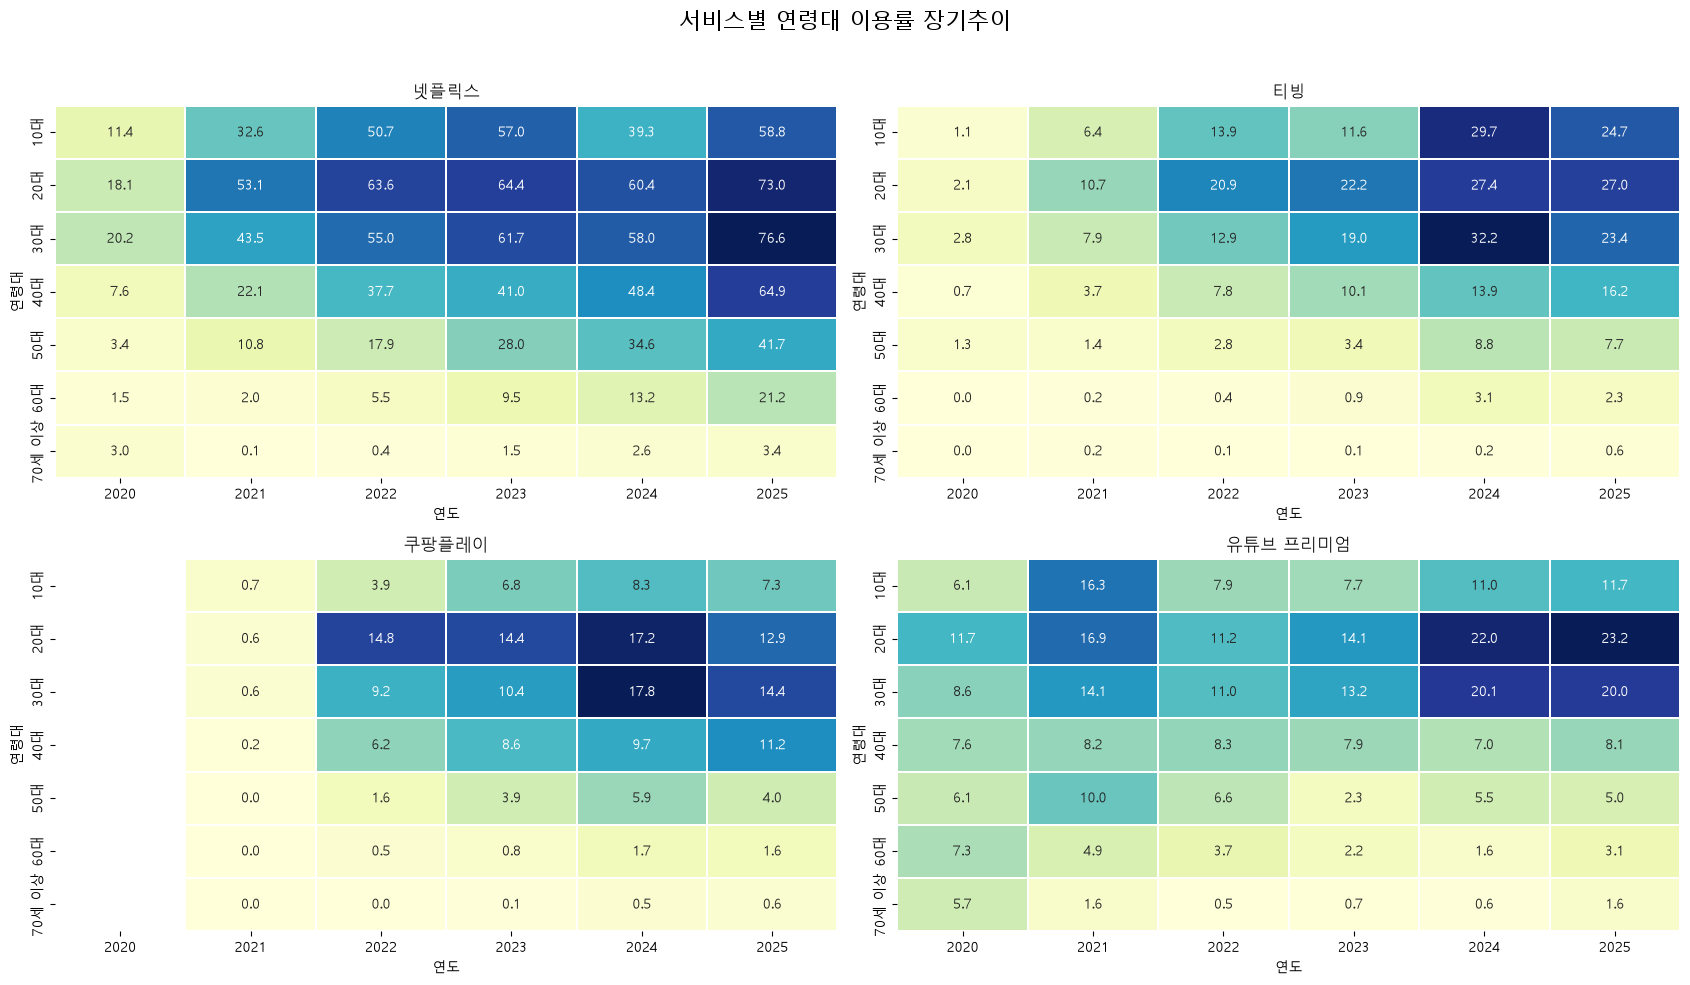

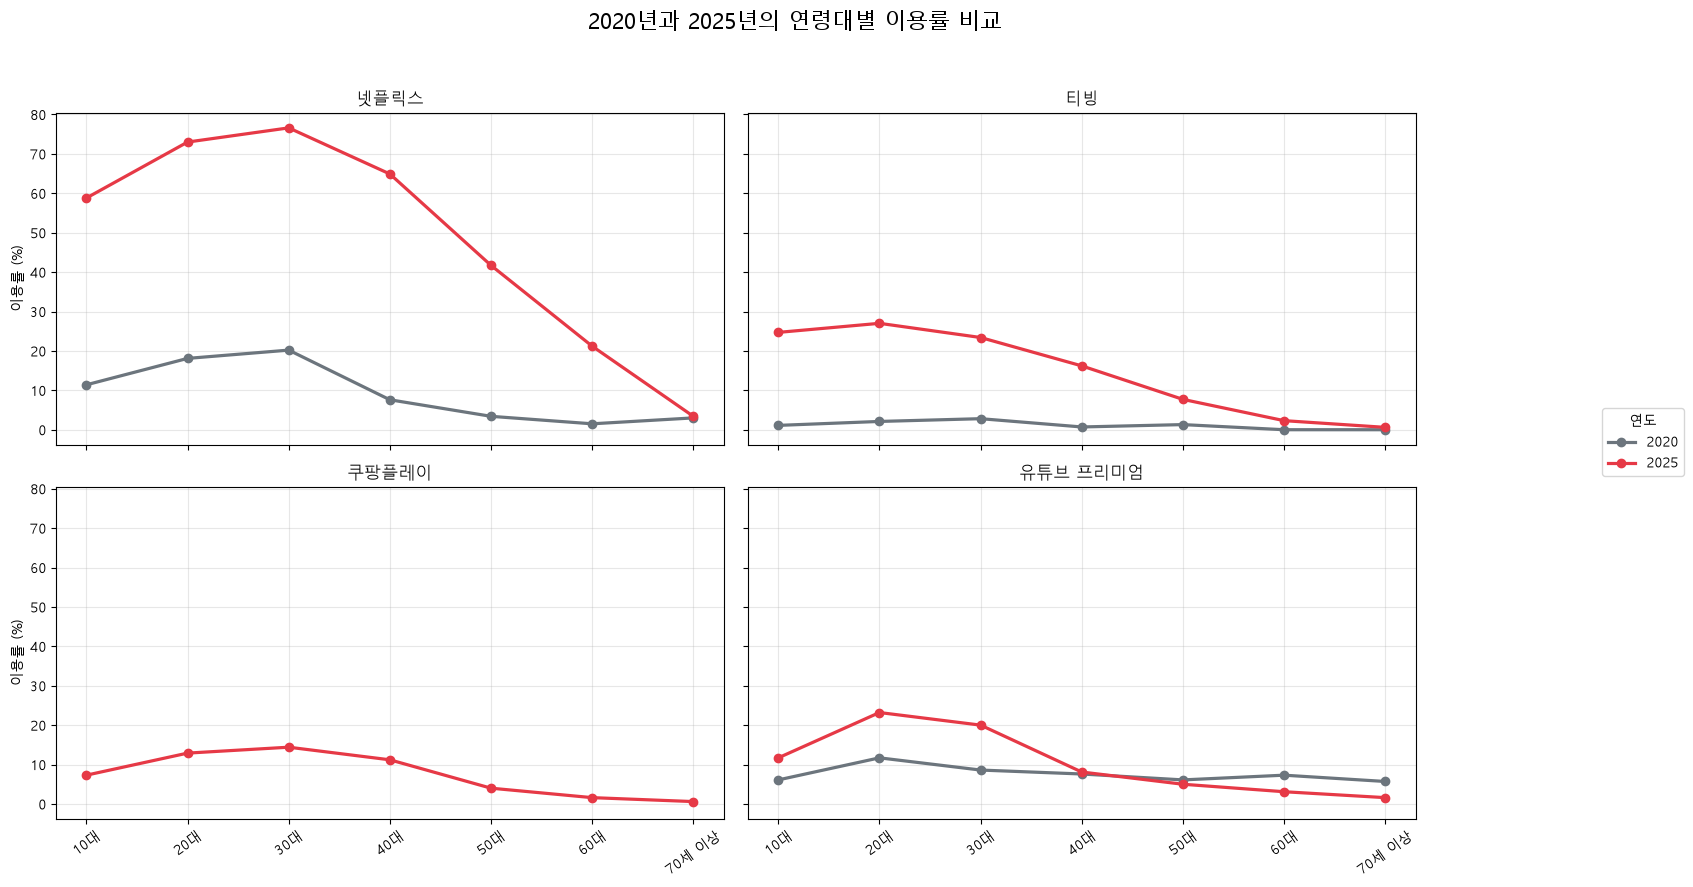

,넷플릭스,티빙,쿠팡플레이,유튜브 프리미엄
구분별(2),,,,
10대,47.400000,23.600000,nan,5.600000
20대,54.900000,24.900000,nan,11.500000
30대,56.400000,20.600000,nan,11.400000
40대,57.300000,15.500000,nan,0.500000
50대,38.300000,6.400000,nan,-1.100000
60대,19.700000,2.300000,nan,-4.200000
70세 이상,0.400000,0.600000,nan,-4.100000


각 연령대에서 1위인 서비스는 2020→2025년 이용률이 가장 크게 증가한 서비스입니다.


In [146]:
age_categories = ["10대", "20대", "30대", "40대", "50대", "60대", "70세 이상"]

# 각 서비스의 연령대별 이용률 변화를 heatmap으로 확인
# fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

for ax, (service_name, keyword) in zip(axes.flat, analysis_services.items()):
    table = demographic_service_data("연령", age_categories, keyword)
    sns.heatmap(table, ax=ax, annot=True, fmt=".1f", cmap="YlGnBu",
                linewidths=0.3, cbar=False)
    ax.set_title(service_name)
    ax.set_xlabel("연도")
    ax.set_ylabel("연령대")

fig.suptitle("서비스별 연령대 이용률 장기추이", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 2020년과 2025년의 연령 프로필을 직접 비교
# fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)

for ax, (service_name, keyword) in zip(axes.flat, analysis_services.items()):
    table = demographic_service_data("연령", age_categories, keyword)
    for year, color in [(analysis_years[0], "#6C757D"), (analysis_years[-1], "#E63946")]:
        ax.plot(age_categories, table[year], marker="o", linewidth=2.3, color=color, label=year)
    ax.set_title(service_name)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("이용률 (%)")
axes[1, 0].set_ylabel("이용률 (%)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="연도", loc="center left", bbox_to_anchor=(1, 0.5))
fig.suptitle("2020년과 2025년의 연령대별 이용률 비교", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

# 연령대마다 2020→2025년 증감폭이 가장 큰 서비스를 순위로 확인
age_growth = pd.DataFrame({
    service_name: first_last_change(demographic_service_data("연령", age_categories, keyword))
    for service_name, keyword in analysis_services.items()
})
age_growth_rank = age_growth.rank(axis=1, ascending=False, method="min").astype("Int64")
display(age_growth.round(1).style.background_gradient(cmap="RdYlGn", axis=None))
print("각 연령대에서 1위인 서비스는 2020→2025년 이용률이 가장 크게 증가한 서비스입니다.")
# display(age_growth_rank)

## 3. 소득: 공통 4개 구간의 장기추이

소득 구간을 임의로 합산하지 않습니다. 표본수·가중치가 없으므로 이용률을 단순 평균하면 왜곡될 수 있기 때문입니다.

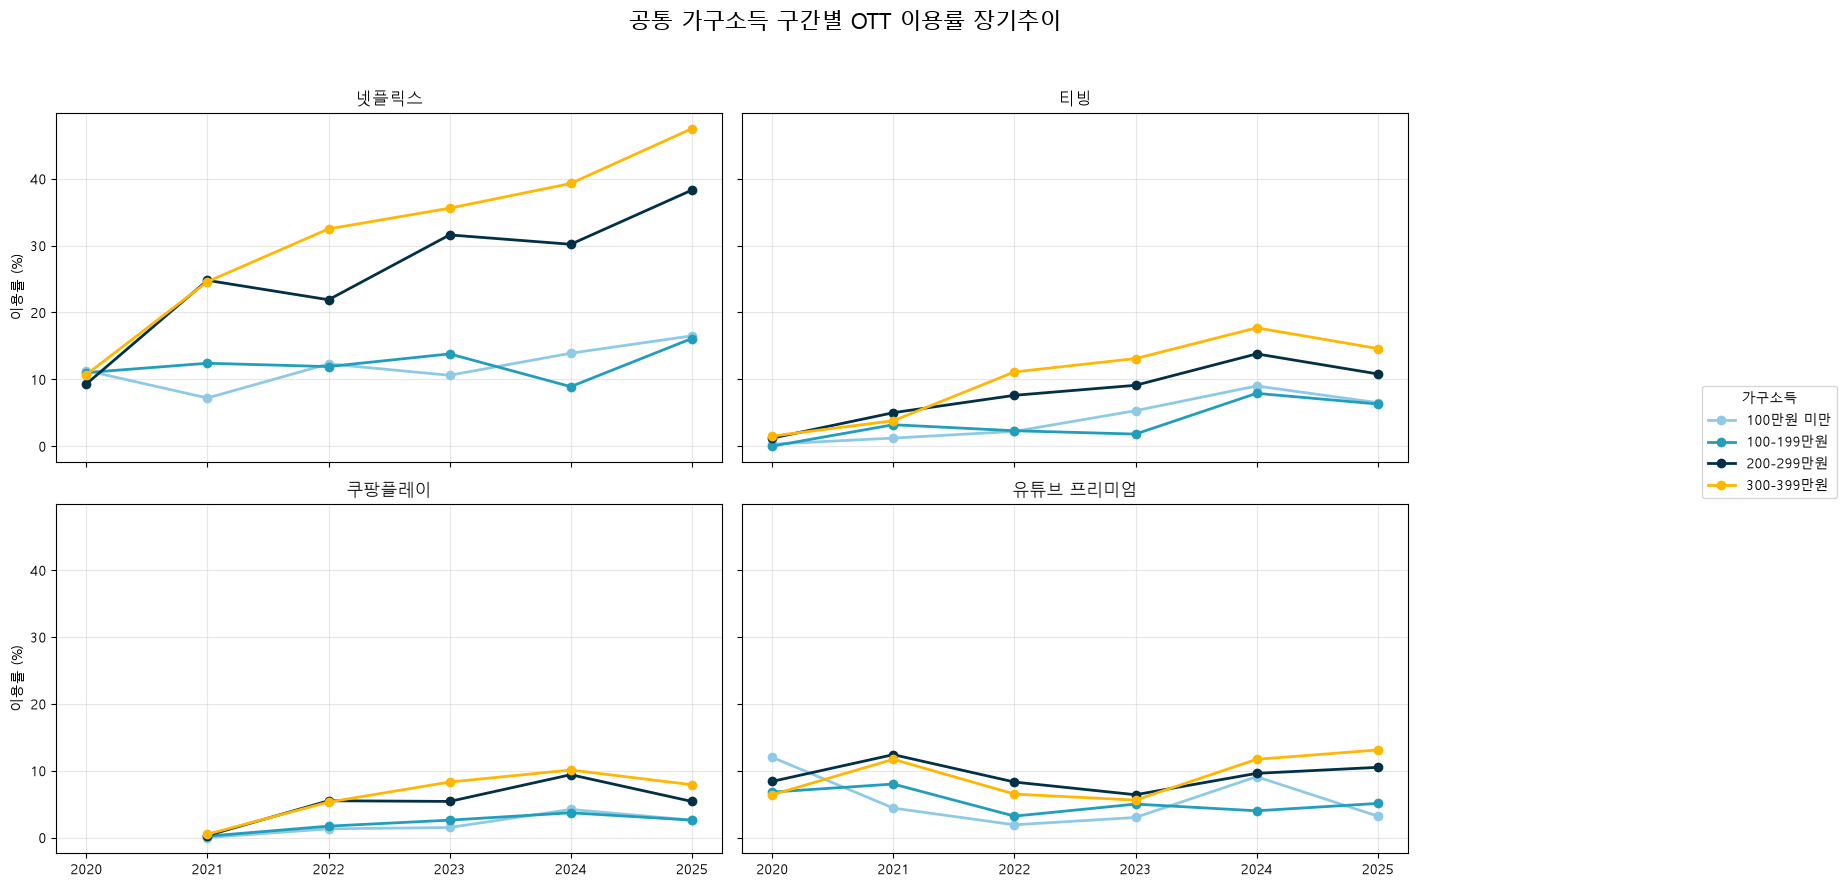

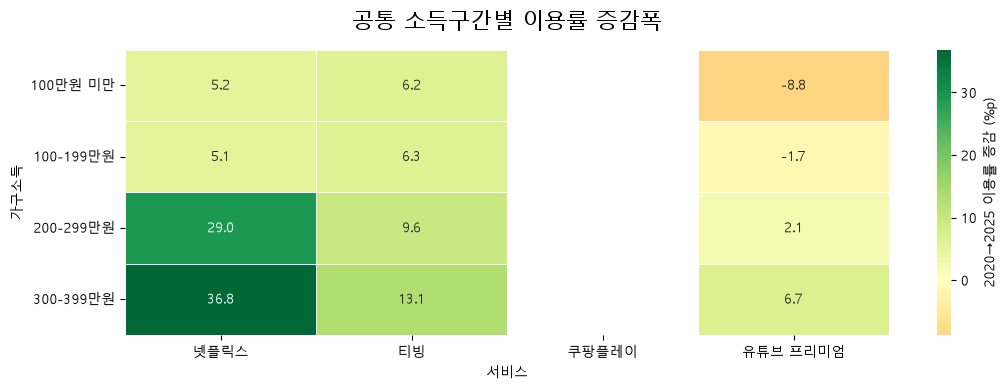

In [147]:
common_income_categories = ["100만원 미만", "100-199만원", "200-299만원", "300-399만원"]
income_colors = ["#8ECAE6", "#219EBC", "#023047", "#FFB703"]

# fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True, sharey=True)
fig, axes = plt.subplots(2, 2, figsize=(17, 9), sharex=True, sharey=True)

for ax, (service_name, keyword) in zip(axes.flat, analysis_services.items()):
    table = demographic_service_data("가구소득", common_income_categories, keyword)
    for income_group, color in zip(common_income_categories, income_colors):
        ax.plot(table.columns, table.loc[income_group], marker="o", linewidth=2,
                color=color, label=income_group)
    ax.set_title(service_name)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("이용률 (%)")
axes[1, 0].set_ylabel("이용률 (%)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="가구소득", loc="center left", bbox_to_anchor=(1, 0.5))
fig.suptitle("공통 가구소득 구간별 OTT 이용률 장기추이", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.84, 0.95])
plt.show()

# 공통 구간에서의 2020→2025 이용률 증감폭
income_growth = pd.DataFrame({
    service_name: first_last_change(demographic_service_data("가구소득", common_income_categories, keyword))
    for service_name, keyword in analysis_services.items()
})
plt.figure(figsize=(11, 4))
sns.heatmap(income_growth, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            linewidths=0.5, cbar_kws={"label": "2020→2025 이용률 증감 (%p)"})
plt.title("공통 소득구간별 이용률 증감폭", fontsize=16, pad=15)
plt.xlabel("서비스")
plt.ylabel("가구소득")
plt.tight_layout()
plt.show()

## 4. 소득: 고소득층 기간 분리 분석

조사 항목이 달라진 고소득층은 하나의 장기 추이로 연결하지 않습니다. 2020~2022년, 2023~2024년, 2025년을 각각 비교합니다.

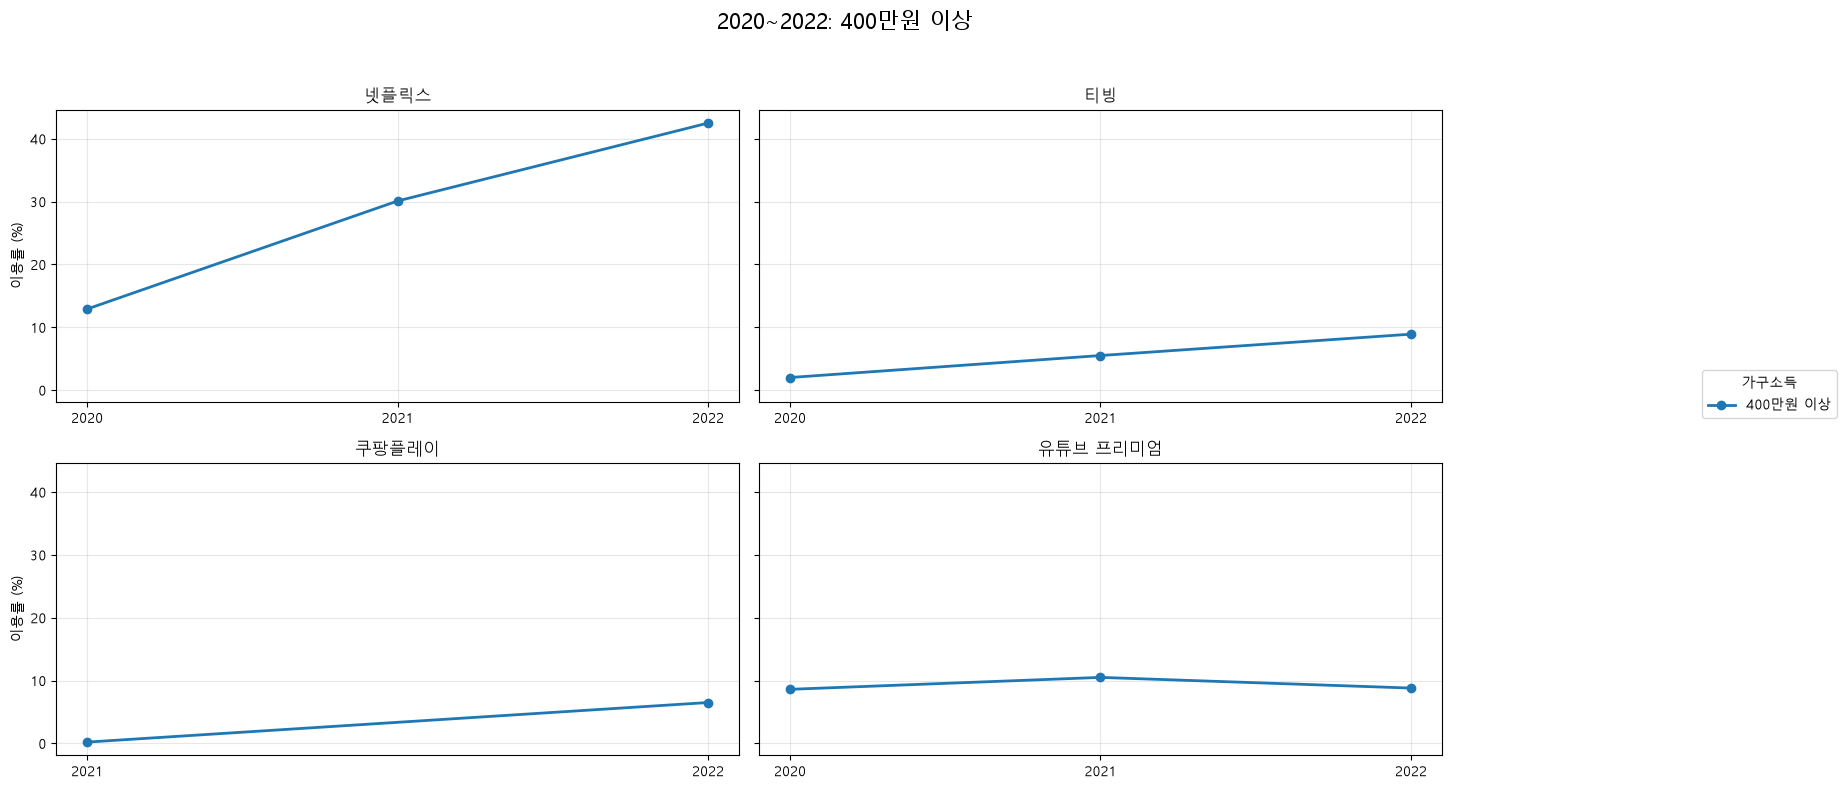

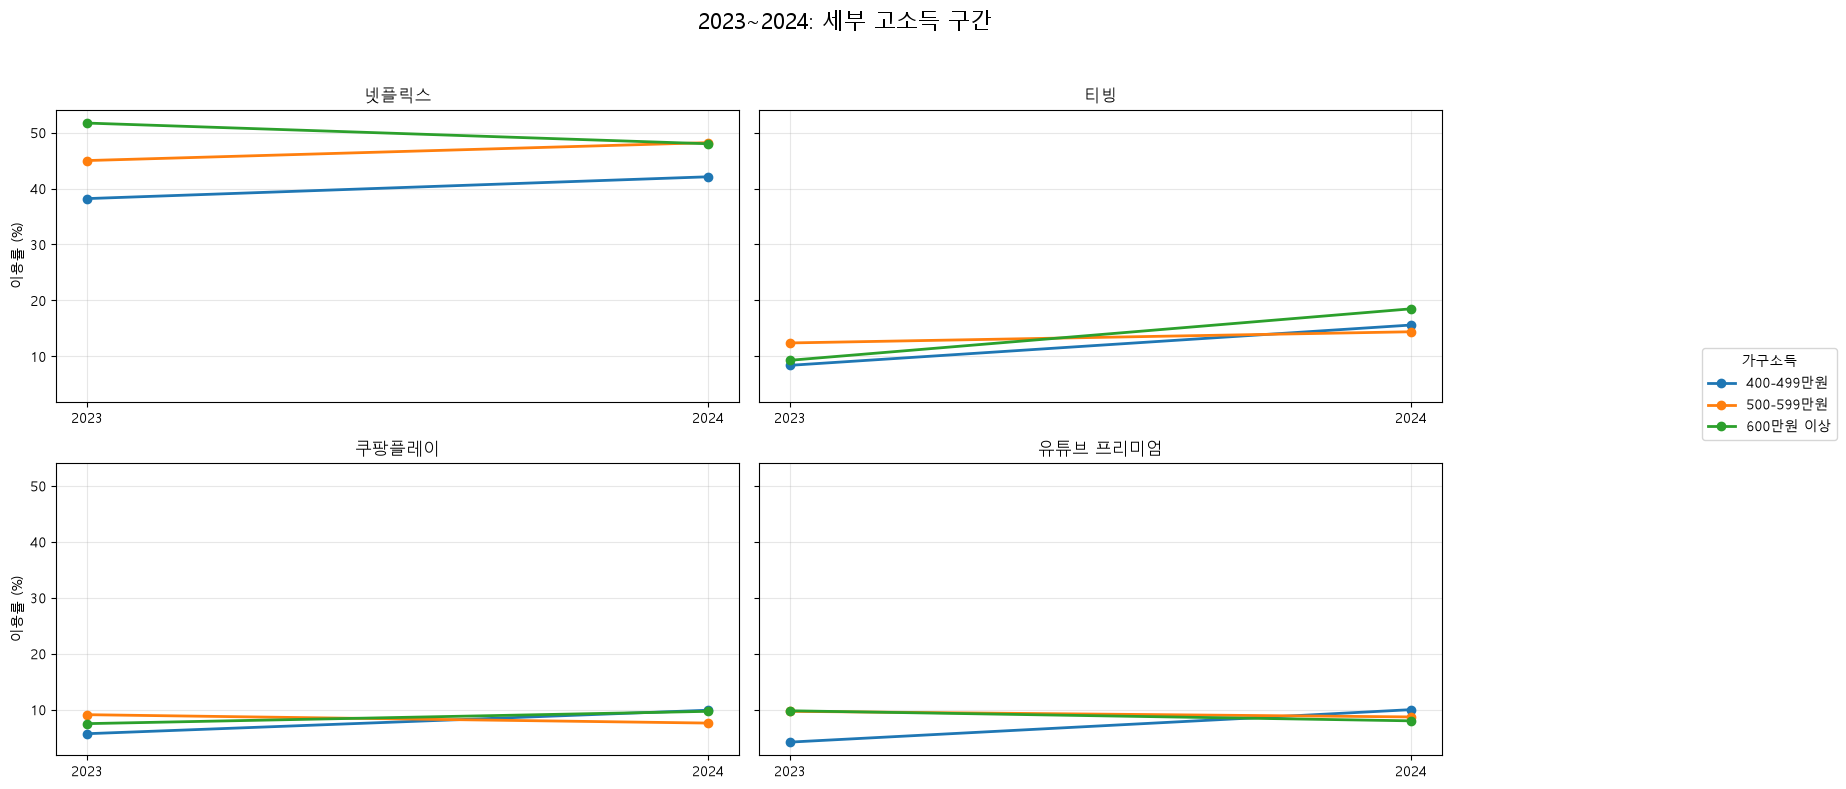

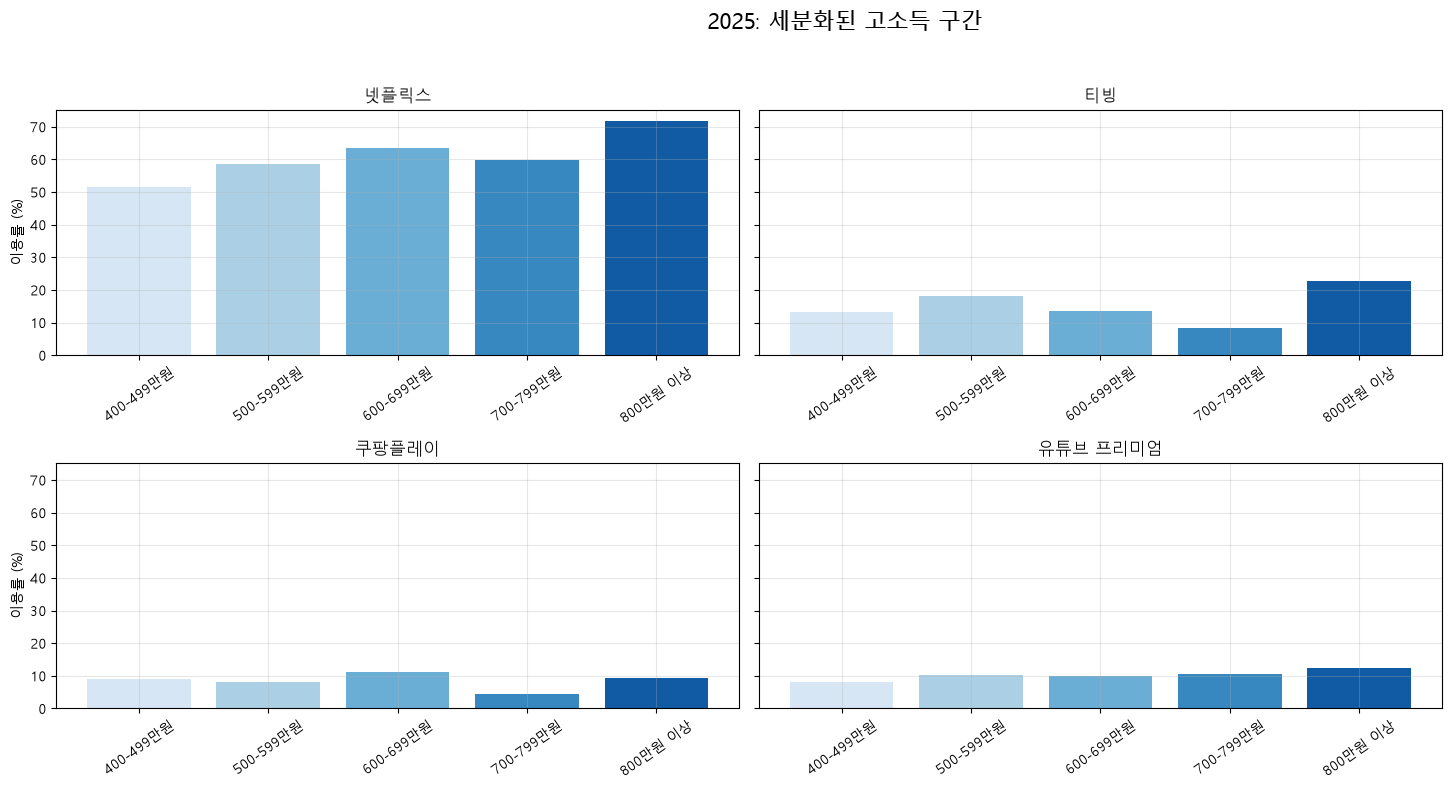

주의: 서로 다른 기간의 고소득 그래프는 조사 구간이 달라 직접적인 증감 비교를 하지 않습니다.


In [148]:
high_income_periods = [
    ("2020~2022: 400만원 이상", ["400만원 이상"], ["2020", "2021", "2022"]),
    ("2023~2024: 세부 고소득 구간", ["400-499만원", "500-599만원", "600만원 이상"], ["2023", "2024"]),
    ("2025: 세분화된 고소득 구간", ["400-499만원", "500-599만원", "600-699만원", "700-799만원", "800만원 이상"], ["2025"]),
]

for period_name, income_groups, period_years in high_income_periods:
    # fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharey=True)
    fig, axes = plt.subplots(2, 2, figsize=(17, 8), sharey=True)
    for ax, (service_name, keyword) in zip(axes.flat, analysis_services.items()):
        table = demographic_service_data("가구소득", income_groups, keyword).reindex(columns=period_years)
        if len(period_years) == 1:
            ax.bar(income_groups, table[period_years[0]], color=sns.color_palette("Blues", len(income_groups)))
            ax.tick_params(axis="x", rotation=35)
        else:
            for income_group in income_groups:
                ax.plot(period_years, table.loc[income_group], marker="o", linewidth=2, label=income_group)
        ax.set_title(service_name)
        ax.grid(alpha=0.3)
    axes[0, 0].set_ylabel("이용률 (%)")
    axes[1, 0].set_ylabel("이용률 (%)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title="가구소득", loc="center left", bbox_to_anchor=(1, 0.5))
    fig.suptitle(period_name, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.86, 0.95])
    plt.show()

print("주의: 서로 다른 기간의 고소득 그래프는 조사 구간이 달라 직접적인 증감 비교를 하지 않습니다.")

#### 5. 인구통계별 핵심 인사이트 표

In [149]:
insight_rows = []
for service_name, keyword in analysis_services.items():
    overall_table = overall_usage[overall_usage["서비스"].str.contains(keyword, regex=False, na=False)].sort_values("연도")
    overall_rates = overall_table.set_index("연도")["이용률"]
    overall_change = overall_rates.get(analysis_years[-1], float("nan")) - overall_rates.get(analysis_years[0], float("nan"))

    service_gender_gap = gender_gap.loc[service_name]
    latest_gender_gap = service_gender_gap.get(analysis_years[-1])
    gender_text = (
        "비교 불가" if pd.isna(latest_gender_gap) else
        (f"여성 우세 {latest_gender_gap:.1f}%p" if latest_gender_gap > 0 else
         f"남성 우세 {-latest_gender_gap:.1f}%p" if latest_gender_gap < 0 else "성별 차이 없음")
    )

    age_table = demographic_service_data("연령", age_categories, keyword)
    latest_age = age_table[analysis_years[-1]]
    top_age = latest_age.idxmax() if latest_age.notna().any() else "비교 불가"

    income_change = first_last_change(demographic_service_data("가구소득", common_income_categories, keyword))
    top_income = income_change.idxmax() if income_change.notna().any() else "비교 불가"
    income_text = "비교 불가" if top_income == "비교 불가" else f"{top_income}에서 +{income_change[top_income]:.1f}%p"

    insight_rows.append({
        "서비스": service_name,
        "전체 이용률 변화 (2020→2025)": "비교 불가" if pd.isna(overall_change) else f"{overall_change:+.1f}%p",
        "2025 성별 특징": gender_text,
        "2025 최고 이용 연령대": top_age,
        "가장 크게 성장한 공통 소득구간": income_text,
    })

insight_table = pd.DataFrame(insight_rows)
display(insight_table)
print("고소득층은 조사 구간이 연도별로 달라 인사이트 표의 장기 소득 비교에서 제외했습니다. 고소득층 그래프는 바로 위 기간 분리 분석에서 해석하세요.")

,서비스,전체 이용률 변화 (2020→2025),2025 성별 특징,2025 최고 이용 연령대,가장 크게 성장한 공통 소득구간
0,넷플릭스,+35.1%p,여성 우세 0.8%p,30대,300-399만원에서 +36.8%p
1,티빙,+11.5%p,여성 우세 2.1%p,20대,300-399만원에서 +13.1%p
2,쿠팡플레이,비교 불가,여성 우세 0.9%p,30대,비교 불가
3,유튜브 프리미엄,+1.4%p,남성 우세 3.0%p,20대,300-399만원에서 +6.7%p


고소득층은 조사 구간이 연도별로 달라 인사이트 표의 장기 소득 비교에서 제외했습니다. 고소득층 그래프는 바로 위 기간 분리 분석에서 해석하세요.


# 주요 OTT 이용률 통계 분석

대상: 넷플릭스·티빙·쿠팡플레이·유튜브 프리미엄. 검정 단위는 2020~2025년의 집단별 이용률입니다.

In [150]:
from itertools import product
from math import erfc, exp, sqrt
from statistics import median

stat_services = {"넷플릭스": "넷플릭스", "티빙": "티빙", "쿠팡플레이": "쿠팡플레이", "유튜브 프리미엄": "유튜브"}
age_categories = ["10대", "20대", "30대", "40대", "50대", "60대", "70세 이상"]

def avg_rank(values):
    order, ranks, start = sorted(range(len(values)), key=lambda i: values[i]), [0.0] * len(values), 0
    while start < len(values):
        end = start
        while end + 1 < len(values) and values[order[end + 1]] == values[order[start]]: end += 1
        for pos in range(start, end + 1): ranks[order[pos]] = (start + end + 2) / 2
        start = end + 1
    return ranks

def wilcoxon_exact(x, y):
    diff = [a - b for a, b in zip(x, y) if pd.notna(a) and pd.notna(b) and a != b]
    if len(diff) < 2: return len(diff), float("nan"), float("nan"), float("nan")
    ranks = avg_rank([abs(d) for d in diff])
    wp, mean_wp = sum(r for d, r in zip(diff, ranks) if d > 0), sum(ranks) / 2
    all_wp = [sum(r for sign, r in zip(signs, ranks) if sign > 0) for signs in product([-1, 1], repeat=len(ranks))]
    p = sum(abs(w - mean_wp) >= abs(wp - mean_wp) - 1e-12 for w in all_wp) / len(all_wp)
    mean_diff = sum(diff) / len(diff)
    sd_diff = sqrt(sum((d - mean_diff) ** 2 for d in diff) / (len(diff) - 1))
    return len(diff), min(wp, sum(ranks) - wp), p, mean_diff / sd_diff if sd_diff else float("nan")

def holm(p_values):
    adjusted, running, order = [0.0] * len(p_values), 0.0, sorted(range(len(p_values)), key=lambda i: p_values[i])
    for rank, index in enumerate(order):
        running = max(running, min(1.0, (len(p_values) - rank) * p_values[index]))
        adjusted[index] = running
    return adjusted

def mann_kendall_sen(values, years):
    pairs = [(float(year), value) for year, value in zip(years, values) if pd.notna(value)]
    if len(pairs) < 3: return len(pairs), float("nan"), float("nan"), float("nan")
    slopes, s = [], 0
    for i in range(len(pairs) - 1):
        for j in range(i + 1, len(pairs)):
            change = pairs[j][1] - pairs[i][1]
            s += (change > 0) - (change < 0)
            slopes.append(change / (pairs[j][0] - pairs[i][0]))
    n = len(pairs); variance = n * (n - 1) * (2 * n + 5) / 18
    z = (s - 1) / sqrt(variance) if s > 0 else (s + 1) / sqrt(variance) if s < 0 else 0
    return n, s, erfc(abs(z) / sqrt(2)), median(slopes)

## 1. 성별: Wilcoxon signed-rank 검정과 Cohen's d

In [ ]:
gender_rows = []
for service_name, keyword in stat_services.items():
    table = demographic_service_data("성별", ["남자", "여자"], keyword)
    n, statistic, p_value, d = wilcoxon_exact(table.loc["여자"], table.loc["남자"])
    gender_rows.append({"서비스": service_name, "비교 연도 수": n, 
                        "여성 평균": table.loc["여자"].mean(), "남성 평균": table.loc["남자"].mean(), 
                        "평균 차이 (여성-남성, %p)": (table.loc["여자"] - table.loc["남자"]).mean(), 
                        "Wilcoxon 통계량": statistic, "p-value (exact)": p_value, 
                        "Cohen's d (paired)": d, 
                        "유의 여부 (0.05)": "유의" if p_value < 0.05 else "유의하지 않음"})

gender_statistics = pd.DataFrame(gender_rows)
display(gender_statistics.round(3))
print("Cohen's d가 양수면 여성 이용률이 높은 방향, 음수면 남성 이용률이 높은 방향입니다.")

,서비스,비교 연도 수,여성 평균,남성 평균,"평균 차이 (여성-남성, %p)",Wilcoxon 통계량,p-value (exact),Cohen's d (paired),유의 여부 (0.05)
0,넷플릭스,6,30.900,30.933,-0.033,7.0,0.562,-0.014,유의하지 않음
1,티빙,6,9.367,7.483,1.883,2.0,0.094,1.059,유의하지 않음
2,쿠팡플레이,5,5.520,5.420,0.100,5.0,0.625,0.087,유의하지 않음
3,유튜브 프리미엄,6,7.400,9.567,-2.167,0.0,0.031,-2.265,유의


Cohen's d가 양수면 여성 이용률이 높은 방향, 음수면 남성 이용률이 높은 방향입니다.


## 2. 연령: Friedman 검정, 유의 시 Wilcoxon 사후검정과 Holm 보정

In [ ]:
friedman_rows, posthoc_rows = [], []
for service_name, keyword in stat_services.items():
    table = demographic_service_data("연령", age_categories, keyword).dropna(axis=1)
    blocks, groups, rank_sums, tie_sum = table.shape[1], table.shape[0], [0.0] * table.shape[0], 0
    for year in table.columns:
        values, ranks = table[year].tolist(), avg_rank(table[year].tolist())
        rank_sums = [total + rank for total, rank in zip(rank_sums, ranks)]
        tie_sum += sum(count ** 3 - count for count in pd.Series(values).value_counts() if count > 1)
    chi_square = 12 * sum(rank_sum ** 2 for rank_sum in rank_sums) / (blocks * groups * (groups + 1)) - 3 * blocks * (groups + 1)
    chi_square /= 1 - tie_sum / (blocks * groups * (groups ** 2 - 1))
    half_x = chi_square / 2
    p_value = exp(-half_x) * (1 + half_x + half_x ** 2 / 2)
    w = chi_square / (blocks * (groups - 1))
    friedman_rows.append({"서비스": service_name, "비교 연도 수": blocks, 
                          "Friedman χ²": chi_square, "p-value": p_value, "Kendall's W": w, 
                          "유의 여부 (0.05)": "유의" if p_value < 0.05 else "유의하지 않음"})
    if p_value < 0.05:
        pairs = []
        for i in range(groups - 1):
            for j in range(i + 1, groups):
                n, statistic, pair_p, d = wilcoxon_exact(table.iloc[i], table.iloc[j])
                pairs.append([i, j, n, statistic, pair_p, d])
        for pair, adjusted_p in zip(pairs, holm([pair[4] for pair in pairs])):
            posthoc_rows.append({"서비스": service_name, "연령대 1": age_categories[pair[0]], 
                                 "연령대 2": age_categories[pair[1]], "원 p-value": pair[4], 
                                 "Holm 보정 p-value": adjusted_p, "Cohen's d": pair[5], 
                                 "유의 여부 (0.05)": "유의" if adjusted_p < 0.05 else "유의하지 않음"})

friedman_statistics = pd.DataFrame(friedman_rows)
display(friedman_statistics.round(3))
if posthoc_rows:
    display(pd.DataFrame(posthoc_rows).round(3))
else:
    print("Friedman 검정에서 유의한 서비스가 없어 사후검정 표는 생성하지 않았습니다.")

,서비스,비교 연도 수,Friedman χ²,p-value,Kendall's W,유의 여부 (0.05)
0,넷플릭스,6,34.500,0.0,0.958,유의
1,티빙,6,32.623,0.0,0.906,유의
2,쿠팡플레이,5,27.120,0.0,0.904,유의
3,유튜브 프리미엄,6,32.579,0.0,0.905,유의


,서비스,연령대 1,연령대 2,원 p-value,Holm 보정 p-value,Cohen's d,유의 여부 (0.05)
0,넷플릭스,10대,20대,0.031,0.656,-2.236,유의하지 않음
1,넷플릭스,10대,30대,0.031,0.656,-1.741,유의하지 않음
2,넷플릭스,10대,40대,0.312,0.656,0.451,유의하지 않음
3,넷플릭스,10대,50대,0.031,0.656,1.687,유의하지 않음
4,넷플릭스,10대,60대,0.031,0.656,2.360,유의하지 않음
...,...,...,...,...,...,...,...
79,유튜브 프리미엄,40대,60대,0.031,0.656,2.006,유의하지 않음
80,유튜브 프리미엄,40대,70세 이상,0.031,0.656,2.877,유의하지 않음
81,유튜브 프리미엄,50대,60대,0.094,0.656,0.898,유의하지 않음
82,유튜브 프리미엄,50대,70세 이상,0.031,0.656,1.400,유의하지 않음


In [153]:
posthoc = pd.DataFrame(posthoc_rows).round(3)
posthoc['유의 여부 (0.05)'].value_counts()

유의 여부 (0.05)
유의하지 않음    84
Name: count, dtype: int64

## 3. 각 집단의 시간 변화: Mann-Kendall 추세 검정과 Sen's slope

In [ ]:
trend_rows = []
for demographic, categories in [("성별", ["남자", "여자"]), ("연령", age_categories)]:
    for service_name, keyword in stat_services.items():
        table = demographic_service_data(demographic, categories, keyword)
        for category in categories:
            n, s, p_value, slope = mann_kendall_sen(table.loc[category], table.columns)
            trend = "유의한 증가" if p_value < 0.05 and slope > 0 else "유의한 감소" if p_value < 0.05 and slope < 0 else "유의하지 않음"
            trend_rows.append({"분석 기준": demographic, "집단": category, "서비스": service_name, 
                               "연도 수": n, "Mann-Kendall S": s, "p-value": p_value, 
                               "Sen's slope (%p/년)": slope, "추세 결론 (0.05)": trend})

trend_statistics = pd.DataFrame(trend_rows)
display(trend_statistics.round(3))
print("Sen's slope이 양수면 연평균 이용률 상승, 음수면 하락 방향입니다. 6개 연도이므로 유의하지 않음은 추세가 없다는 뜻이 아니라 검정력이 낮을 수 있다는 뜻입니다.")

,분석 기준,집단,서비스,연도 수,Mann-Kendall S,p-value,Sen's slope (%p/년),추세 결론 (0.05)
0,성별,남자,넷플릭스,6,15,0.009,6.450,유의한 증가
1,성별,여자,넷플릭스,6,13,0.024,5.600,유의한 증가
2,성별,남자,티빙,6,13,0.024,2.033,유의한 증가
3,성별,여자,티빙,6,13,0.024,2.750,유의한 증가
4,성별,남자,쿠팡플레이,5,8,0.086,1.963,유의하지 않음
5,성별,여자,쿠팡플레이,5,10,0.027,1.050,유의한 증가
6,성별,남자,유튜브 프리미엄,6,3,0.707,0.200,유의하지 않음
7,성별,여자,유튜브 프리미엄,6,2,0.851,0.025,유의하지 않음
8,연령,10대,넷플릭스,6,11,0.060,6.975,유의하지 않음
9,연령,20대,넷플릭스,6,11,0.060,5.650,유의하지 않음


Sen's slope이 양수면 연평균 이용률 상승, 음수면 하락 방향입니다. 6개 연도이므로 유의하지 않음은 추세가 없다는 뜻이 아니라 검정력이 낮을 수 있다는 뜻입니다.


# OTT 미이용자 통계 분석

In [ ]:
# '이용한적 없음' 응답을 성별·연령별로 분석한다.
no_use_keyword = "이용한적 없음"
no_use_years = sorted(df_long["연도"].unique(), key=int)
age_groups = ["10대", "20대", "30대", "40대", "50대", "60대", "70세 이상"]

def no_use_table(group, categories):
    data = df_long[(df_long["구분별(1)"] == group) & (df_long["구분별(2)"].isin(categories)) & (df_long["서비스"].str.contains(no_use_keyword, regex=False, na=False))]
    return data.pivot_table(index="구분별(2)", columns="연도", values="이용률", aggfunc="first").reindex(index=categories, columns=no_use_years)

# 질문 1: 성별 미이용률 차이
gender_no_use = no_use_table("성별", ["남자", "여자"])
n, statistic, p_value, cohens_d = wilcoxon_exact(gender_no_use.loc["여자"], gender_no_use.loc["남자"])
gender_result = pd.DataFrame([{"비교 연도 수": n, "남성 평균 미이용률": gender_no_use.loc["남자"].mean(), 
                               "여성 평균 미이용률": gender_no_use.loc["여자"].mean(), 
                               "평균 차이 (여성-남성, %p)": (gender_no_use.loc["여자"] - gender_no_use.loc["남자"]).mean(), 
                               "Wilcoxon 통계량": statistic, "p-value (exact)": p_value, "Cohen's d (paired)": cohens_d, 
                               "결론 (0.05)": "성별 차이 유의" if p_value < 0.05 else "성별 차이 유의하지 않음"}])
print("[질문 1] 성별 미이용률과 Wilcoxon 검정")
display(gender_no_use)
display(gender_result.round(3))

# 질문 2: 연령대별 미이용 수준
age_no_use = no_use_table("연령", age_groups)
age_result = pd.DataFrame({"2020 미이용률": age_no_use[no_use_years[0]], "2025 미이용률": age_no_use[no_use_years[-1]], 
                           "변화량 (%p)": age_no_use[no_use_years[-1]] - age_no_use[no_use_years[0]], 
                           "6년 평균 미이용률": age_no_use.mean(axis=1)}).sort_values("2025 미이용률", ascending=False)
highest_by_year = pd.DataFrame({"미이용률 최다 연령대": age_no_use.idxmax(axis=0)})
highest_by_year["미이용률 (%)"] = [age_no_use.loc[age, year] for year, age in highest_by_year["미이용률 최다 연령대"].items()]
print("[질문 2] 연령대별 미이용률 요약")
display(age_result.round(1))
display(highest_by_year.round(1))

# 질문 3: 각 성별·연령대의 장기 감소 추세
trend_rows = []
for group, categories in [("성별", ["남자", "여자"]), ("연령", age_groups)]:
    table = no_use_table(group, categories)
    for category in categories:
        n, s, trend_p, slope = mann_kendall_sen(table.loc[category], table.columns)
        trend = "유의한 감소" if trend_p < 0.05 and slope < 0 else "유의한 증가" if trend_p < 0.05 and slope > 0 else "유의하지 않음"
        trend_rows.append({"분석 기준": group, "집단": category, 
                           "2020 미이용률": table.loc[category, no_use_years[0]], 
                           "2025 미이용률": table.loc[category, no_use_years[-1]], 
                           "총 변화량 (%p)": table.loc[category, no_use_years[-1]] - table.loc[category, no_use_years[0]], 
                           "Mann-Kendall S": s, "p-value": trend_p, "Sen's slope (%p/년)": slope, "추세 결론 (0.05)": trend})
no_use_trend_result = pd.DataFrame(trend_rows)
print("[질문 3] 집단별 미이용률 감소 추세")
display(no_use_trend_result.round(3))
print("Sen's slope이 음수면 미이용률이 줄어드는 방향입니다.")

[질문 1] 성별 미이용률과 Wilcoxon 검정


연도,2020,2021,2022,2023,2024,2025
구분별(2),,,,,,
남자,77.3,66.0,59.5,55.7,49.3,46.3
여자,79.3,64.5,60.0,56.5,55.7,46.5


,비교 연도 수,남성 평균 미이용률,여성 평균 미이용률,"평균 차이 (여성-남성, %p)",Wilcoxon 통계량,p-value (exact),Cohen's d (paired),결론 (0.05)
0,6,59.017,60.417,1.4,4.0,0.219,0.519,성별 차이 유의하지 않음


[질문 2] 연령대별 미이용률 요약


,2020 미이용률,2025 미이용률,변화량 (%p),6년 평균 미이용률
구분별(2),,,,
70세 이상,91.4,94.9,3.5,96.2
60대,91.3,75.0,-16.3,86.6
50대,89.6,52.5,-37.1,69.8
40대,82.4,27.1,-55.3,52.7
10대,79.6,26.2,-53.4,44.2
30대,69.9,15.6,-54.3,34.2
20대,66.6,15.3,-51.3,29.5


,미이용률 최다 연령대,미이용률 (%)
연도,,
2020,70세 이상,91.4
2021,70세 이상,98.2
2022,70세 이상,98.8
2023,70세 이상,97.5
2024,70세 이상,96.4
2025,70세 이상,94.9


[질문 3] 집단별 미이용률 감소 추세


,분석 기준,집단,2020 미이용률,2025 미이용률,총 변화량 (%p),Mann-Kendall S,p-value,Sen's slope (%p/년),추세 결론 (0.05)
0,성별,남자,77.3,46.3,-31.0,-15,0.009,-5.567,유의한 감소
1,성별,여자,79.3,46.5,-32.8,-15,0.009,-4.500,유의한 감소
2,연령,10대,79.6,26.2,-53.4,-11,0.060,-7.450,유의하지 않음
3,연령,20대,66.6,15.3,-51.3,-13,0.024,-5.900,유의한 감소
4,연령,30대,69.9,15.6,-54.3,-15,0.009,-6.133,유의한 감소
5,연령,40대,82.4,27.1,-55.3,-15,0.009,-10.350,유의한 감소
6,연령,50대,89.6,52.5,-37.1,-15,0.009,-7.467,유의한 감소
7,연령,60대,91.3,75.0,-16.3,-13,0.024,-3.260,유의한 감소
8,연령,70세 이상,91.4,94.9,3.5,-3,0.707,-0.600,유의하지 않음


Sen's slope이 음수면 미이용률이 줄어드는 방향입니다.


## OTT 이용 경험 없음 비율의 연도별 변화

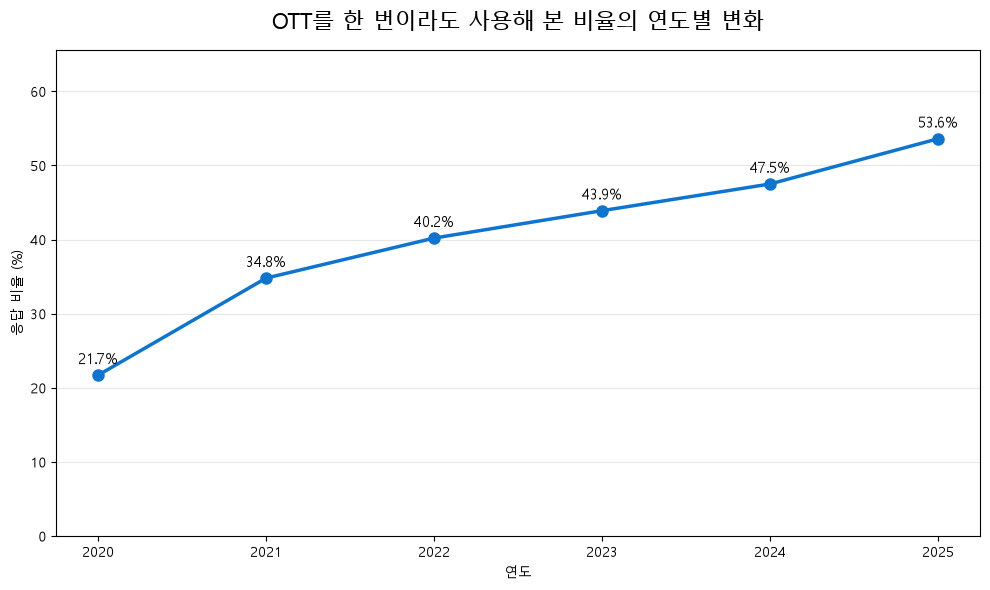

In [156]:
# 전체 응답자 중 조사 대상 OTT를 이용한 적이 없다고 응답한 비율
no_experience_overall = overall_usage[
    overall_usage["서비스"].str.contains("이용한적 없음", regex=False, na=False)
].sort_values("연도")

no_experience_overall["이용률"] = 100 - no_experience_overall["이용률"]

plt.figure(figsize=(10, 6))
plt.plot(
    no_experience_overall["연도"], no_experience_overall["이용률"],
    marker="o", markersize=8, linewidth=2.5, color="#0D75CF"
)
for year, rate in zip(no_experience_overall["연도"], no_experience_overall["이용률"]):
    plt.text(year, rate + 1.5, f"{rate:.1f}%", ha="center", fontsize=11)

plt.title("OTT를 한 번이라도 사용해 본 비율의 연도별 변화", fontsize=16, pad=15)
plt.xlabel("연도")
plt.ylabel("응답 비율 (%)")
plt.ylim(0, no_experience_overall["이용률"].max() + 12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()